<a href="https://colab.research.google.com/github/ashishkushwah734-bot/Adaptive-Network-Traffic-Anomaly-Classification/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data...
Saved EDA chart as 'class_distribution.png'
Preprocessing features...
Training Decision Tree...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     13422
           1       0.97      0.99      0.98     11773

    accuracy                           0.98     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       0.98      0.98      0.98     25195


--- Top 5 Features for Streamlit App ---
['src_bytes', 'protocol_type', 'dst_host_srv_count', 'hot', 'dst_bytes']

Saved 'dt_model.pkl' and 'scaler.pkl'. Download these to your PC for Phase 4.


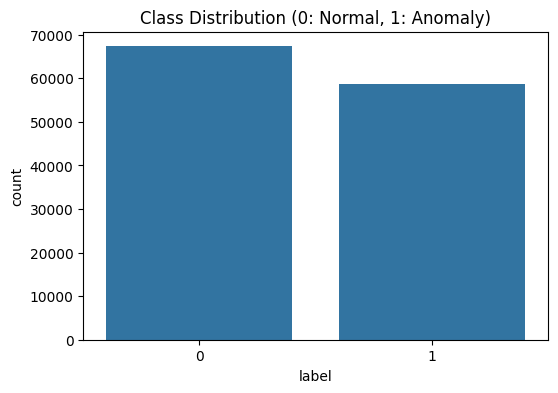

In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Standard NSL-KDD Columns
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty_level'
]

# Load Dataset
print("Loading data...")
df = pd.read_csv('/content/KDDTrain+.txt', names=columns)

# Drop difficulty level as it's an artificial Kaggle metric, not a network feature
df = df.drop('difficulty_level', axis=1)

# 2. Binary Target Mapping (Normal = 0, Anomaly = 1)
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Generate a quick EDA chart for your paper
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title("Class Distribution (0: Normal, 1: Anomaly)")
plt.savefig("class_distribution.png")
print("Saved EDA chart as 'class_distribution.png'")

# 3. Preprocessing
print("Preprocessing features...")
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = [c for c in df.columns if c not in categorical_cols and c != 'label']

# Encode categoricals
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Split data
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numericals
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 4. Train Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# 5. Evaluate
y_pred = dt.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 6. Extract Top 5 Features for Streamlit Prototype
importances = pd.Series(dt.feature_importances_, index=X.columns)
top_5 = importances.nlargest(5).index.tolist()
print("\n--- Top 5 Features for Streamlit App ---")
print(top_5)

# 7. Save Model and Scaler
joblib.dump(dt, 'dt_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nSaved 'dt_model.pkl' and 'scaler.pkl'. Download these to your PC for Phase 4.")

In [5]:
# Extract only the top 5 features
top_5_features = ['src_bytes', 'protocol_type', 'dst_host_srv_count', 'hot', 'dst_bytes']
numerical_lite = ['src_bytes', 'dst_host_srv_count', 'hot', 'dst_bytes']

X_lite = df[top_5_features]
y_lite = df['label']

X_train_lite, X_test_lite, y_train_lite, y_test_lite = train_test_split(X_lite, y_lite, test_size=0.2, random_state=42)

# Create a specialized scaler just for the 4 numerical features we are keeping
scaler_lite = StandardScaler()
X_train_lite.loc[:, numerical_lite] = scaler_lite.fit_transform(X_train_lite[numerical_lite])

# Train the lightweight Streamlit model
dt_lite = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_lite.fit(X_train_lite, y_train_lite)

# Save the Streamlit-ready files
joblib.dump(dt_lite, 'dt_lite.pkl')
joblib.dump(scaler_lite, 'scaler_lite.pkl')
print("Saved 'dt_lite.pkl' and 'scaler_lite.pkl'. Download these for Streamlit!")

Saved 'dt_lite.pkl' and 'scaler_lite.pkl'. Download these for Streamlit!


/tmp/ipykernel_473/1082726477.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.00749435 -0.00752856 -0.00752856 ... -0.00752856 -0.00747917
 -0.00752168]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_lite.loc[:, numerical_lite] = scaler_lite.fit_transform(X_train_lite[numerical_lite])
/tmp/ipykernel_473/1082726477.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.25803847 -1.02761573 -0.9734105  ... -0.99147891  1.25803847
  1.24900426]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train_lite.loc[:, numerical_lite] = scaler_lite.fit_transform(X_train_lite[numerical_lite])
/tmp/ipykernel_473/1082726477.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.09490

In [6]:
from google.colab import files

files.download('dt_lite.pkl')
files.download('scaler_lite.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
